# 03. Lattice dynamics & annealing

- **Part A — 教程**:用 `RydbergSystem` 跑 0-1-r lattice 的最小例子(共振 420 Rabi + blockade),熟悉 API。
- **Part B — 生产 runner**:Route-2 π/2 cell、checkerboard 绝热制备、TN anneal smoke test、15×15 production、batch 结果。

两个 Part 各自自包含。合并自 `01r_lattice_dynamics`(教程)+ `03_lattice_dynamics_and_annealing`(生产)。

In [ ]:
# Pin BLAS/OpenMP to 1 thread BEFORE importing numpy/scipy/tenpy.
# Small TN tensors (DMRG/TDVP/PEPS) => multi-threaded BLAS oversubscribes
# cores and runs 10-40x SLOWER on a loaded box. This cell must stay first
# and run before any import: the libraries read these variables only once,
# at import time.
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
           "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ.setdefault(_v, "1")
print("BLAS/OpenMP threads pinned to", os.environ.get("OMP_NUM_THREADS"))

## Part A — 教程:0-1-r lattice dynamics(共振 420 Rabi drive)

This notebook is the canonical example for using the `RydbergSystem`
universal class to simulate a 0-1-r Rydberg lattice.

**Physics.** Each atom has three local levels: hyperfine `|0⟩`, hyperfine
`|1⟩`, and Rydberg `|r⟩`. The 420 nm laser drives the `|1⟩ ↔ |r⟩` transition
(effective two-photon channel `drive_R`). We start in `|111…⟩` (every atom in
the hyperfine `|1⟩` state), apply a constant resonant Rabi pulse, and
measure the Rydberg occupation `⟨n_r⟩` per site.

**Lattice size.** A literal 4×4 lattice has Hilbert dimension `3**16 ≈ 4.3 × 10⁷`,
which is intractable for exact (sparse) evolution. We use a 2×2 lattice
(dim 81) so the notebook runs in seconds; for true 4×4 dynamics use the
tensor-network backend in `tn_common`.

**API tour.** We exercise the three pieces of the new core API:
1. `RydbergSystem.set_atom_level(level_structure).set_atom_geom(geometry).set_protocol(...)` —
   build a universal system that owns the lattice, the energy-level
   spec, and the time-dependent protocol all in one place.
2. `simulate(system, x, psi0)` — evolve under the protocol-bound
   Hamiltonian. The protocol is already on the system, so the call
   signature is just `(system, x, initial_state)`.
3. `system.expectation(observable_name, psi)` — measure per-site
   observables that the system registered automatically (`n_r_0`,
   `n_r_1`, …, `sum_n_r`).

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ryd_gate.backends.exact import simulate
from ryd_gate import RydbergSystem
from ryd_gate.lattice import Register
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol

## 1. Build the lattice geometry

`Register.rectangle` lives in `ryd_gate.lattice` — pure geometry, no
Hamiltonians or level structure. Spacing is in microns; for this demo
we set it large enough that the van der Waals shift is small compared
to the Rabi frequency (no blockade, clean single-atom Rabi flopping).

In [2]:
Lx, Ly = 2, 2
geometry = Register.rectangle(Lx, Ly, spacing_um=20.0)
N = geometry.N
print(f"Lattice: {Lx}×{Ly} = {N} atoms, spacing = {geometry.spacing_um} μm")
print(f"Coordinates (μm):\n{geometry.coords}")

Lattice: 2×2 = 4 atoms, spacing = 20.0 μm
Coordinates (μm):
[[ 0.  0.]
 [ 0. 20.]
 [20.  0.]
 [20. 20.]]


## 2. Define the protocol: resonant constant 420 Rabi

`DigitalAnalogProtocol` is function-based: pass `omega_R_fn(t)`, `delta_R_fn(t)`, … and `n_steps`. For a constant resonant 420 drive we use `omega_R_fn=lambda t: Omega_R`, `delta_R_fn=lambda t: 0.0` (resonant), hyperfine off. Natural units: `Omega_R = 2π`, so one Rabi period = 1 time unit.

In [3]:
Omega_R = 2 * np.pi          # 1 × (2π/Omega) Rabi period
T_GATE = 2.0                 # evolve for two Rabi periods
N_STEPS = 200                # piecewise-constant slices for the sparse backend

protocol = DigitalAnalogProtocol(
    t_gate=T_GATE,
    omega_R_fn=lambda t: Omega_R,   # constant resonant 420 drive
    delta_R_fn=lambda t: 0.0,       # resonant
    n_steps=N_STEPS,
)

## 3. Build the `RydbergSystem`

Three ingredients go into the constructor: geometry, level-structure
name (`"01r"`), and the protocol we just defined. The system pre-builds
every Hamiltonian block and observable the backends will need.

We pass `InteractionSpec(C6=0.0)` to disable van der Waals here so the
Rabi oscillation is exactly the single-atom result, atom-by-atom
independent. (Turn `C6` back on to see Rydberg blockade.)

In [4]:
from ryd_gate import InteractionSpec

system = (
    RydbergSystem
    .set_atom_level("01r")
    .set_atom_geom(geometry, interaction=InteractionSpec(C6=0.0))
    .set_protocol(protocol)
)

print(f"Local levels       : {system.basis.local_levels}")
print(f"Hilbert dim        : {system.dim}  (= {system.basis.local_dim}^{N})")
print(f"Registered blocks  : {sorted(system.blocks.list())[:8]} …")
print(f"Per-site Rydberg obs: {[f'n_r_{i}' for i in range(N)]}")

Local levels       : ('0', '1', 'r')
Hilbert dim        : 81  (= 3^4)
Registered blocks  : ['H_vdw', 'delta_R', 'delta_hf', 'drive_R', 'drive_R_0', 'drive_R_1', 'drive_R_2', 'drive_R_3'] …
Per-site Rydberg obs: ['n_r_0', 'n_r_1', 'n_r_2', 'n_r_3']


## 4. Prepare the |1111⟩ initial state

`product_state` takes a per-site list of level labels and returns the
corresponding computational basis vector. It validates that every label
is a valid level for this system.

In [5]:
psi0 = system.product_state(["1"] * N)
print(f"|1{'1'*(N-1)}⟩ norm                 : {np.linalg.norm(psi0):.6f}")
print(f"⟨sum_n_r⟩ at t = 0 (sanity): {system.expectation('sum_n_r', psi0):.6f}")

|1111⟩ norm                 : 1.000000
⟨sum_n_r⟩ at t = 0 (sanity): 0.000000


## 5. Evolve under the resonant drive

Because the protocol is already bound to the system, `simulate` takes
only `(system, x, psi0)`. `DigitalAnalogProtocol` has no free
parameters (the schedule lives on the protocol object), so `x = []`.
`t_eval` is the grid at which we keep intermediate states for plotting.

In [6]:
t_eval = np.linspace(0.0, T_GATE, 81)
result = simulate(system, [], psi0, t_eval=t_eval)

print(f"Evolved for {result.times[-1]:.3f} time units across {len(result.times)} points")
print(f"Final-state norm : {np.linalg.norm(result.psi_final):.6f}")

Evolved for 2.000 time units across 200 points
Final-state norm : 1.000000


## 6. Measure per-site Rydberg occupation

`system.expectation(name, psi)` evaluates a registered observable on a
state vector. The per-site observables `n_r_0 … n_r_{N-1}` are created
automatically during construction; their lattice average is `sum_n_r / N`.

In [7]:
n_r_per_site = np.array([
    [system.expectation(f"n_r_{i}", psi) for psi in result.states]
    for i in range(N)
])
mean_n_r = n_r_per_site.mean(axis=0)

# Analytic single-atom expectation (no interactions): sin^2(Omega_R t / 2)
analytic = np.sin(Omega_R * result.times / 2.0) ** 2

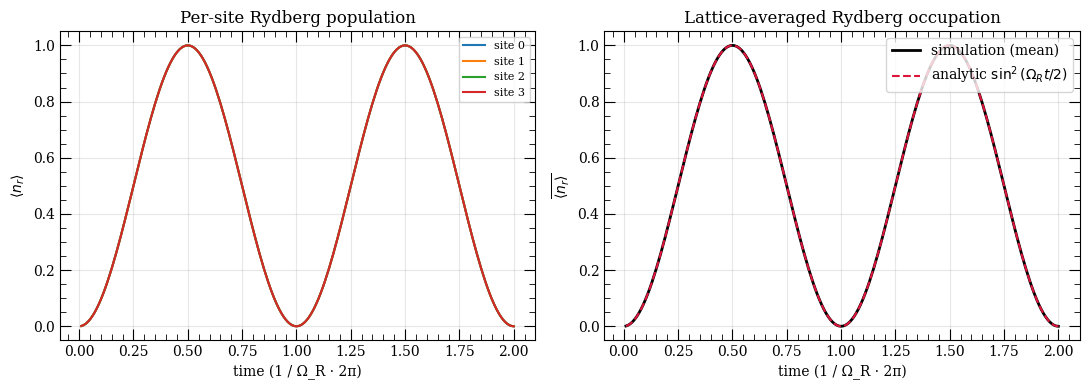

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for i in range(N):
    axes[0].plot(result.times, n_r_per_site[i], label=f"site {i}")
axes[0].set_xlabel("time (1 / Ω_R · 2π)")
axes[0].set_ylabel(r"$\langle n_r \rangle$")
axes[0].set_title("Per-site Rydberg population")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].plot(result.times, mean_n_r, color="black", lw=2, label="simulation (mean)")
axes[1].plot(result.times, analytic, color="crimson", ls="--", lw=1.5,
             label=r"analytic $\sin^2(\Omega_R t / 2)$")
axes[1].set_xlabel("time (1 / Ω_R · 2π)")
axes[1].set_ylabel(r"$\overline{\langle n_r \rangle}$")
axes[1].set_title("Lattice-averaged Rydberg occupation")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

All four sites trace out identical $\sin^2(\Omega_R t / 2)$ curves and
the lattice mean matches the analytic single-atom prediction — expected
with `C6 = 0`, because every atom evolves independently.

## 7. Bonus: turn on van der Waals to see Rydberg blockade

The same system, with default `C6` and a smaller spacing, becomes
strongly interacting. Each pair within the blockade radius cannot be
doubly excited, so the lattice-averaged Rydberg occupation saturates
well below 0.5.

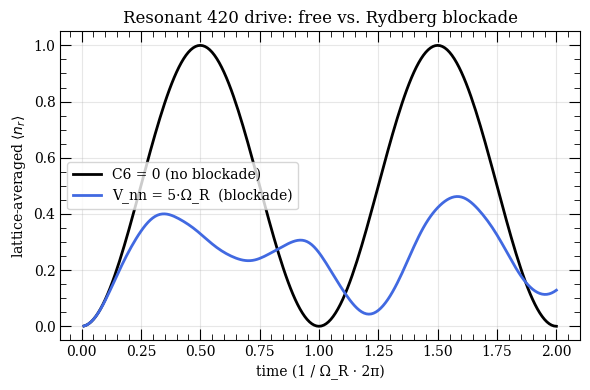

In [9]:
spacing_um = 5.0
V_nn_target = 5.0 * Omega_R                # 5× the Rabi frequency → strong blockade
C6_blockade = V_nn_target * spacing_um ** 6

geometry_dense = Register.rectangle(Lx, Ly, spacing_um=spacing_um)
system_blockade = (
    RydbergSystem
    .set_atom_level("01r")
    .set_atom_geom(geometry_dense, interaction=InteractionSpec(C6=C6_blockade))
    .set_protocol(DigitalAnalogProtocol(
        t_gate=T_GATE, omega_R_fn=lambda t: Omega_R, delta_R_fn=lambda t: 0.0, n_steps=N_STEPS,
    ))
)

psi0_b = system_blockade.product_state(["1"] * N)
res_b = simulate(system_blockade, [], psi0_b, t_eval=t_eval)

mean_n_r_blockade = np.array([
    system_blockade.expectation("sum_n_r", psi) / N
    for psi in res_b.states
])

plt.figure(figsize=(6, 4))
plt.plot(result.times, mean_n_r, color="black", lw=2, label="C6 = 0 (no blockade)")
plt.plot(res_b.times, mean_n_r_blockade, color="royalblue", lw=2,
         label=f"V_nn = {V_nn_target / Omega_R:.0f}·Ω_R  (blockade)")
plt.xlabel("time (1 / Ω_R · 2π)")
plt.ylabel(r"lattice-averaged $\langle n_r \rangle$")
plt.title("Resonant 420 drive: free vs. Rydberg blockade")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary of the API used

| Step | Call |
|---|---|
| Geometry | `Register.rectangle(Lx, Ly, spacing_um=...)` |
| Protocol (constant resonant Rabi) | `DigitalAnalogProtocol(t_gate=..., omega_R_fn=lambda t: Omega_R, ...)` |
| Universal system | `RydbergSystem.set_atom_level("01r").set_atom_geom(geometry).set_protocol(...)` |
| Initial state | `system.product_state(["1"] * N)` |
| Evolve | `simulate(system, [], psi0, t_eval=...)` |
| Observable | `system.expectation("n_r_<i>", psi)` |

For lattices beyond exact-state memory (true 4×4 = `3**16 ≈ 43M` states) use a `TNLatticeSpec` + `simulate_tn` from `tn_common`.

## Part B — Lattice dynamics & annealing(生产 runner)

整合 `run_route2_lattice_cell` / `run_3level_lattice` / `run_15x15_anneal` / `run_anneal_batch`。
exact 小系统直接跑;TN 大系统默认 `RUN_TN_SMOKE=False` dry-run。

## 0. Notebook setup

准备 repo path + lattice/anneal API。exact 小系统直接跑;TN 大系统默认 `RUN_TN_SMOKE=False` dry-run。

In [ ]:
from pathlib import Path
import os
import sys
import json
from itertools import product

os.environ.setdefault("JAX_PLATFORMS", "cpu")

HERE = Path.cwd().resolve()
if HERE.name == "notebooks":
    REPO_ROOT = HERE.parents[1]
elif HERE.name == "scripts":
    REPO_ROOT = HERE.parent
else:
    REPO_ROOT = HERE
os.chdir(REPO_ROOT)

for extra in (REPO_ROOT / "src", REPO_ROOT / "scripts"):
    if str(extra) not in sys.path:
        sys.path.insert(0, str(extra))

import numpy as np
import matplotlib.pyplot as plt

from ryd_gate import RydbergSystem
from ryd_gate.backends.exact import simulate
from ryd_gate import InteractionSpec
from ryd_gate.lattice import Register, plot_spatial_rydberg
from ryd_gate.protocols.digital_analog import DigitalAnalogProtocol
from ryd_gate.analysis.observables import measure_rydberg_occupation, precompute_trit_masks, staggered_magnetization
from ryd_gate.backends.tn_common import create_tn_lattice_spec, simulate_tn
from ryd_gate.protocols.lattice_dynamics import TFIMAnnealProtocol

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print(f"Repo root: {REPO_ROOT}")


In [ ]:
# Local compatibility shim: the kernel DigitalAnalogProtocol is now function-
# based (omega_R_fn(t), ...). These notebooks keep their piecewise-constant
# Segment schedules and lower them to step functions here. Note the backend
# integrates on n_steps uniform slices, so segment edges should be resolved
# by a generous n_steps (the notebooks already scale it with len(segments)).
from dataclasses import dataclass

import numpy as np


@dataclass
class Segment:
    duration: float
    omega_R: "float | np.ndarray" = 0.0
    omega_hf: "float | np.ndarray" = 0.0
    delta_R: "float | np.ndarray" = 0.0
    delta_hf: "float | np.ndarray" = 0.0


def segments_protocol(segments, n_steps=200):
    """Build the function-based DigitalAnalogProtocol from constant segments."""
    segments = list(segments)
    edges = np.cumsum([0.0] + [float(seg.duration) for seg in segments])

    def step_fn(name):
        values = [getattr(seg, name) for seg in segments]

        def fn(t):
            j = int(np.clip(np.searchsorted(edges, t, side="right") - 1, 0, len(values) - 1))
            return values[j]

        return fn

    protocol = DigitalAnalogProtocol(
        t_gate=float(edges[-1]),
        omega_R_fn=step_fn("omega_R"),
        omega_hf_fn=step_fn("omega_hf"),
        delta_R_fn=step_fn("delta_R"),
        delta_hf_fn=step_fn("delta_hf"),
        n_steps=n_steps,
    )
    protocol.segments = segments  # keep the schedule inspectable for plotting
    return protocol


## 1. Route-2 lattice cell: single Rydberg π/2 pulse

从 `|11…>` 出发对 3×3 lattice 施加共振 Rydberg `π/2` pulse:每个 site 的 `|1>`、`|r>` population 应接近 1/2,末态与 product `(|1>-i|r>)/√2` 高 overlap——route-2 中生成 local superposition 的基本 cell。

In [ ]:
OMEGA_R = 2 * np.pi * 200e6
Lx, Ly = 3, 3
spacing = 10.0
geom = Register.rectangle(Lx, Ly, spacing_um=spacing)
N = geom.N

t_pi2_R = np.pi / (2 * OMEGA_R)
proto_direct = segments_protocol([Segment(duration=t_pi2_R, omega_R=OMEGA_R)], n_steps=200)
system_route2 = (
    RydbergSystem
    .set_atom_level("01r")
    .set_atom_geom(geom, interaction=InteractionSpec())
    .set_protocol(proto_direct)
)
psi0 = system_route2.product_state(["1"] * N)
result = simulate(system_route2, [], psi0, t_eval=True)
times = np.concatenate([[0.0], result.times])
if isinstance(result.states, np.ndarray) and result.states.ndim == 2:
    states = [psi0] + [result.states[k] for k in range(result.states.shape[0])]
else:
    states = [psi0, *result.states]

levels = tuple(system_route2.basis.local_levels)
pops_site = {
    i: {lvl: np.array([system_route2.expectation(f"n_{lvl}_{i}", psi) for psi in states]) for lvl in levels}
    for i in range(N)
}
psi_final = states[-1]
psi_plus = sum(
    (-1j) ** sum(c == "r" for c in cfg) * system_route2.product_state(list(cfg))
    for cfg in product(["1", "r"], repeat=N)
) / (2 ** (N / 2))
fidelity = np.abs(np.vdot(psi_plus, psi_final)) ** 2
print(f"N={N}, fidelity to product (|1>-i|r>)/sqrt(2): {fidelity:.6f}")

colors = {"0": "tab:gray", "1": "tab:blue", "r": "tab:red"}
fig, axes = plt.subplots(Ly, Lx, figsize=(3.2 * Lx, 2.7 * Ly), sharex=True, sharey=True)
for i in range(N):
    ix, iy = i // Ly, i % Ly
    ax = axes[iy, ix]
    for lvl in ("0", "1", "r"):
        ax.plot(times / t_pi2_R, pops_site[i][lvl], color=colors[lvl], lw=2, label=rf"$n_{lvl}$")
    ax.axhline(0.5, color="k", ls=":", lw=1)
    ax.set_title(f"site ({ix}, {iy})")
    if i == 0:
        ax.legend(loc="center right", fontsize=8)
for ax in axes[-1, :]:
    ax.set_xlabel(r"time / $t_{\pi/2}$")
for ax in axes[:, 0]:
    ax.set_ylabel("population")
fig.suptitle(r"Route 2: single $\pi/2$ Rydberg pulse on a 3x3 lattice")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(10, 6), sharex=True)
fields = [("omega_R", r"$\Omega_R$"), ("omega_hf", r"$\Omega_{hf}$"), ("delta_R", r"$\Delta_R$"), ("delta_hf", r"$\Delta_{hf}$")]
t_edges = [0.0]
for seg in proto_direct.segments:
    t_edges.append(t_edges[-1] + seg.duration)
for ax, (field, label) in zip(axes, fields):
    t_pts, y_pts = [], []
    for j, seg in enumerate(proto_direct.segments):
        value = getattr(seg, field)
        t_pts.extend([t_edges[j], t_edges[j + 1]])
        y_pts.extend([value, value])
    ax.step(t_pts, y_pts, where="post", lw=2)
    ax.axhline(0, color="k", ls=":", lw=0.8)
    ax.set_ylabel(label)
axes[-1].set_xlabel("time (s)")
fig.suptitle("Digital-analog protocol schedule")
fig.tight_layout()
plt.show()


## 2. Exact 3-level lattice sweep to a checkerboard pattern

从 `|11…>` 出发扫 `|1>↔|r>` detuning,在 Rydberg interaction 下制备 checkerboard 有序态:末态 Rydberg occupation 两子格交替、staggered magnetization 非零——小 lattice exact dynamics 捕捉 blockade 诱导的空间有序。

In [ ]:
Lx, Ly = 3, 3
geom_cb = Register.rectangle(Lx, Ly, spacing_um=5.0)
n_steps = 300
delta_start = -2 * np.pi * 40e6
delta_end = 2 * np.pi * 40e6
t_sweep = 1.5e-6
omega_R = 2 * np.pi * 5e6
dt = t_sweep / n_steps
segments = [
    Segment(duration=dt, omega_R=omega_R, delta_R=delta_start + (delta_end - delta_start) * (k + 0.5) / n_steps)
    for k in range(n_steps)
]
protocol_cb = segments_protocol(segments, n_steps=n_steps)
system_cb = (
    RydbergSystem
    .set_atom_level("01r")
    .set_atom_geom(geom_cb, interaction=InteractionSpec(mode="all"))
    .set_protocol(protocol_cb)
)
psi0_cb = system_cb.product_state(["1"] * geom_cb.N)
print(f"Exact Hilbert dimension: 3^{geom_cb.N} = {3 ** geom_cb.N}")
result_cb = simulate(system_cb, [], psi0_cb)

masks = precompute_trit_masks(geom_cb.N)
occ_final = measure_rydberg_occupation(result_cb.psi_final, masks)
ms = staggered_magnetization(occ_final, geom_cb.sublattice)
print(f"Final staggered magnetization m_s = {ms:.4f}")

fig = plot_spatial_rydberg(
    geom_cb.coords,
    occ_final,
    geom_cb.sublattice,
    title=f"3x3 checkerboard after adiabatic sweep (m_s={ms:.2f})",
)
plt.show()

if result_cb.states is not None:
    occ_traj = measure_rydberg_occupation(result_cb.states, masks)
    fig, ax = plt.subplots(figsize=(8, 4.8))
    for i in range(geom_cb.N):
        color = "tab:red" if geom_cb.sublattice[i] > 0 else "tab:blue"
        ax.plot(result_cb.times * 1e6, occ_traj[i], color=color, alpha=0.7, lw=1.2)
    ax.set_xlabel("time (us)")
    ax.set_ylabel(r"$P_r$ per site")
    ax.set_title("Rydberg occupation during checkerboard sweep")
    fig.tight_layout()
    plt.show()


## 3. Tensor-network anneal smoke test

默认只构造 4×4 配置并 dry-run 打印;`RUN_TN_SMOKE=True` 后用 `simulate_tn` 运行并画 observable traces。公开 TN 后端:`peps`(默认,保留二维几何)、`mps`(CPU reference)。

In [ ]:
RUN_TN_SMOKE = False

Lx, Ly = 4, 4
backend = "peps"
spec = create_tn_lattice_spec(
    Lx,
    Ly,
    V_nn=24.0,
    Omega=2.0,
    level_structure="1r",
    interaction_mode="nn",
    ordering="snake",
)
protocol = TFIMAnnealProtocol(
    hx_peak=1.0,
    hx_initial=0.0,
    hx_final=0.0,
    hz_initial=4.0,
    hz_final=-4.0,
    t_rise=2.0,
    t_sweep=8.0,
    t_fall=2.0,
)
t_eval = np.linspace(0.0, protocol.t_gate, 13)
observables = ["sigma_z", "czz_centerline"]
backend_options = {
    "chi_max": 64,
    "dt": 0.1,
    "svd_min": 1e-10,
    "update_environment": "ntu",
    "measurement_environment": "bp",
    "use_cuda": False,
}
# Alternative reference / validation backends:
# backend = "mps"
# backend_options = {"chi_max": 256, "dt": 0.1, "svd_min": 1e-10}

config = {
    "Lx": spec.Lx,
    "Ly": spec.Ly,
    "N": spec.N,
    "backend": backend,
    "protocol": {"hx_peak": 1.0, "hz_initial": 4.0, "hz_final": -4.0, "t_gate": protocol.t_gate},
    "observables": observables,
    "t_eval_steps": len(t_eval),
    "backend_options": backend_options,
}
print(json.dumps(config, indent=2, sort_keys=True))

if RUN_TN_SMOKE:
    result_tn = simulate_tn(
        spec,
        protocol,
        [],
        initial_state="all_ground",
        backend=backend,
        t_eval=t_eval,
        observables=observables,
        backend_options=backend_options,
    )
    obs = result_tn.metadata.get("obs") or {}
    for name, values in obs.items():
        arr = np.asarray(values)
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(result_tn.times, arr.reshape(len(result_tn.times), -1).mean(axis=1), "o-")
        ax.set_xlabel("time")
        ax.set_ylabel(name)
        ax.set_title(f"TN observable: {name}")
        fig.tight_layout()
        plt.show()
else:
    print("Dry-run only. Set RUN_TN_SMOKE=True to invoke the selected backend.")


## 4. Production 15×15 configuration

只展示 15×15 production 配置(lattice / backend / bond dim / observable),不默认运行——给大系统 benchmark 一个可复现入口,同时避免昂贵执行。

In [ ]:
production = {
    "notebook_equivalent": "Set Lx=Ly=15 in the TN configuration cell and enable RUN_TN_SMOKE with the desired backend/output handling.",
    "Lx": 15,
    "Ly": 15,
    "backend_choices": ["peps", "mps"],
    "default_observables": ["sigma_z", "czz_centerline"],
    "recommended_note": "Use peps as the main 2D lattice backend; use mps as a CPU reference.",
}
print(json.dumps(production, indent=2))


## 5. Anneal I/II batch results

扫描 `scripts/results/anneal_batch/*.npz`:有结果就画,没有就显示等价命令——集中检查不同 schedule/sweep/backend 的 observable(main.tex Anneal I/II)。

In [ ]:
batch_dir = REPO_ROOT / "scripts" / "results" / "anneal_batch"
files = sorted(batch_dir.glob("*.npz")) if batch_dir.exists() else []

if not files:
    print("No cached batch .npz files found.")
    print("Example command:")
    print("Use the Anneal I/II configuration in this notebook, or build the same run_config dictionary and call simulate_tn directly.")
else:
    print(f"Found {len(files)} batch file(s).")
    for path in files[:6]:
        data = np.load(path, allow_pickle=False)
        print(f"\n{path.name}: arrays = {list(data.files)}")
        if "times" not in data.files:
            continue
        times = data["times"]
        obs_keys = [k for k in data.files if k.startswith("obs_")]
        for key in obs_keys:
            arr = np.asarray(data[key])
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.plot(times, arr.reshape(len(times), -1).mean(axis=1), "o-")
            ax.set_xlabel("time")
            ax.set_ylabel(key.replace("obs_", ""))
            ax.set_title(path.name)
            fig.tight_layout()
            plt.show()
